In [27]:
import pandas as pd

orders = pd.read_csv("D:\Datathon\data\orders.csv")
payments = pd.read_csv("D:\Datathon\data\payments.csv")

orders['order_date'] = pd.to_datetime(orders['order_date'])

df = orders.merge(payments, on='order_id', how='left')

df = df[['customer_id', 'order_date', 'payment_value']]

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_1348\1229953692.py:3: SyntaxWarning: invalid escape sequence '\D'
  orders = pd.read_csv("D:\Datathon\data\orders.csv")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_1348\1229953692.py:4: SyntaxWarning: invalid escape sequence '\D'
  payments = pd.read_csv("D:\Datathon\data\payments.csv")


In [28]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)
print("snapshot_date: ", snapshot_date)

snapshot_date:  2023-01-01 00:00:00


In [29]:
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,  # recency
    'customer_id': 'count',  # frequency
    'payment_value': 'sum'   # monetary
})

rfm.rename(columns={
    'order_date': 'recency',
    'customer_id': 'frequency',
    'payment_value': 'monetary'
}, inplace=True)

rfm = rfm.reset_index()
rfm

,customer_id,recency,frequency,monetary
0,1,617,6,142803.47
1,2,179,4,204693.89
2,3,3443,3,52093.47
3,4,917,1,10939.06
4,5,1376,5,64179.86
...,...,...,...,...
90241,157554,229,1,6263.81
90242,157555,1292,2,95613.85
90243,157557,2039,1,5670.72
90244,157561,860,22,544675.90


# Quantile-Based RFM Score

## 1. Tính RFM theo quantile

In [30]:
rfm_q = rfm.copy()

rfm_q["R_score"] = pd.qcut(rfm_q["recency"].rank(method='first'), q=5, labels=[5,4,3,2,1])

rfm_q["F_score"] = pd.qcut(rfm_q["frequency"].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm_q["M_score"] = pd.qcut(rfm_q["monetary"].rank(method='first'), q=5, labels=[1,2,3,4,5])

rfm_q["RFM_score"] = (rfm_q["R_score"].astype(str) + 
                      rfm_q["F_score"].astype(str) + 
                      rfm_q["M_score"].astype(str))
rfm_q

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,1,617,6,142803.47,4,4,4,444
1,2,179,4,204693.89,5,3,4,534
2,3,3443,3,52093.47,1,2,2,122
3,4,917,1,10939.06,3,1,1,311
4,5,1376,5,64179.86,3,3,3,333
...,...,...,...,...,...,...,...,...
90241,157554,229,1,6263.81,5,2,1,521
90242,157555,1292,2,95613.85,3,2,3,323
90243,157557,2039,1,5670.72,2,2,1,221
90244,157561,860,22,544675.90,3,5,5,355


In [31]:
def rfm_segment(row):
    r, f, m = int(row["R_score"]), int(row["F_score"]), int(row["M_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Hibernating"
    else:
        return "About to Sleep / Potential" 

rfm_q["rfm_segment"] = rfm_q.apply(rfm_segment, axis=1)
rfm_q[["customer_id", "RFM_score", "rfm_segment"]].head()

,customer_id,RFM_score,rfm_segment
0,1,444,Champions
1,2,534,Loyal Customers
2,3,122,Hibernating
3,4,311,About to Sleep / Potential
4,5,333,Loyal Customers


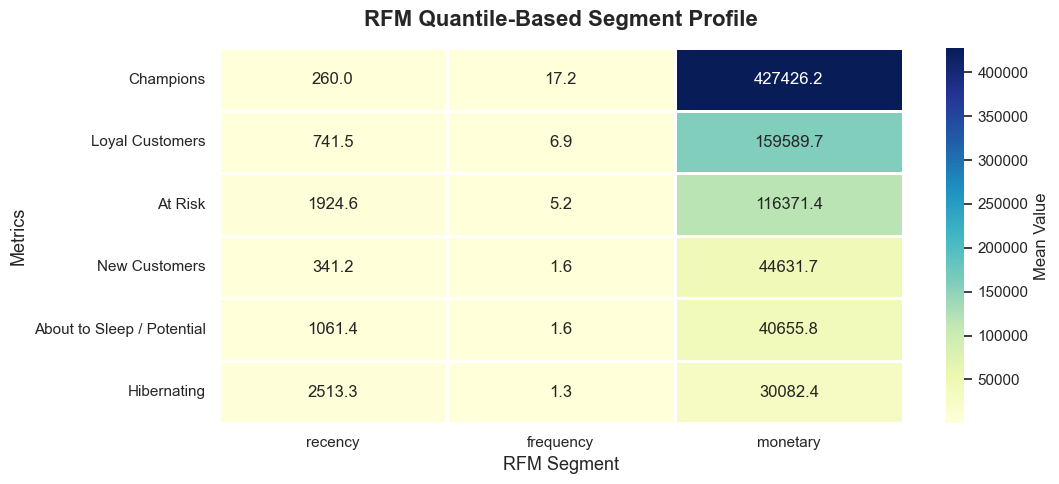

In [32]:
segment_profile_q = (
    rfm_q
    .groupby("rfm_segment")[["recency", "frequency", "monetary"]]
    .mean()
    .sort_values("monetary", ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

plt.figure(figsize=(11, 5))
ax = sns.heatmap(
    segment_profile_q,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Mean Value"}
)

ax.set_title("RFM Quantile-Based Segment Profile", fontsize=16, weight="bold", pad=16)
ax.set_xlabel("RFM Segment", fontsize=13)
ax.set_ylabel("Metrics", fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(
    df,
    customer_id_col='customer_id',
    datetime_col='order_date',
    monetary_value_col='payment_value'
)

summary

,frequency,recency,T,monetary_value
customer_id,,,,
1,5.0,3195.0,3811.0,26035.216000
2,3.0,3211.0,3389.0,46145.050000
3,2.0,336.0,3778.0,22462.055000
4,0.0,0.0,916.0,0.000000
5,4.0,2421.0,3796.0,9482.315000
...,...,...,...,...
157554,0.0,0.0,228.0,0.000000
157555,1.0,1571.0,2862.0,78599.780000
157557,0.0,0.0,2038.0,0.000000


In [34]:
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter

bgf = BetaGeoFitter()
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

ggf = GammaGammaFitter()
summary_gg = summary[summary["monetary_value"] > 0]

ggf.fit(summary_gg["frequency"], summary_gg["monetary_value"])


<lifetimes.GammaGammaFitter: fitted with 67769 subjects, p: 1.18, q: 67.08, v: 1387073.21>

In [35]:
summary["CLV_6m"] = ggf.customer_lifetime_value(
    bgf,
    summary["frequency"],
    summary["recency"],
    summary["T"],
    summary["monetary_value"],
    time=6,               # 6 tháng
    discount_rate=0.01,   # discount rate
    freq="D"
)
summary

,frequency,recency,T,monetary_value,CLV_6m
customer_id,,,,,
1,5.0,3195.0,3811.0,26035.216000,5600.327352
2,3.0,3211.0,3389.0,46145.050000,4320.305427
3,2.0,336.0,3778.0,22462.055000,727.135293
4,0.0,0.0,916.0,0.000000,2398.437944
5,4.0,2421.0,3796.0,9482.315000,4078.572211
...,...,...,...,...,...
157554,0.0,0.0,228.0,0.000000,5225.240224
157555,1.0,1571.0,2862.0,78599.780000,2245.265735
157557,0.0,0.0,2038.0,0.000000,1274.242948


In [36]:
summary["CLV_segment"] = pd.qcut(
    summary["CLV_6m"],
    q=[0, 0.7, 0.9, 1.0],
    labels=["Low Future Value", "Medium Future Value", "High Future Value"]
)

summary["CLV_segment"].value_counts()

CLV_segment
Low Future Value       63172
Medium Future Value    18049
High Future Value       9025
Name: count, dtype: int64

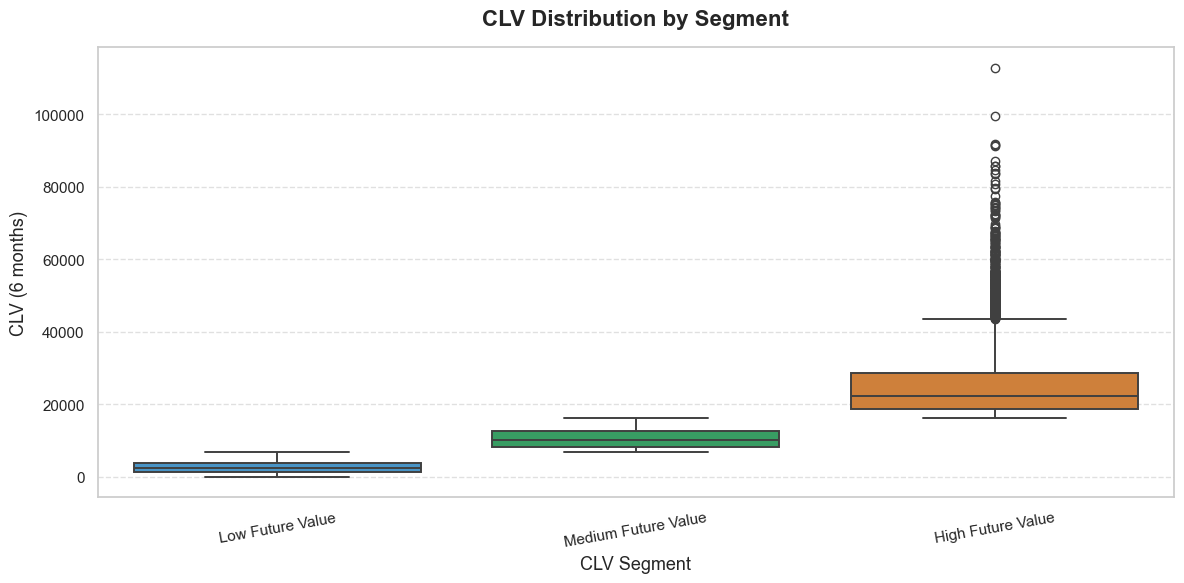

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    x="CLV_segment",
    y="CLV_6m",
    data=summary,
    palette=["#3498db", "#27ae60", "#e67e22"],
    linewidth=1.4
)

ax.set_title("CLV Distribution by Segment", fontsize=16, weight="bold", pad=16)
ax.set_xlabel("CLV Segment", fontsize=13)
ax.set_ylabel("CLV (6 months)", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.6, axis="y")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

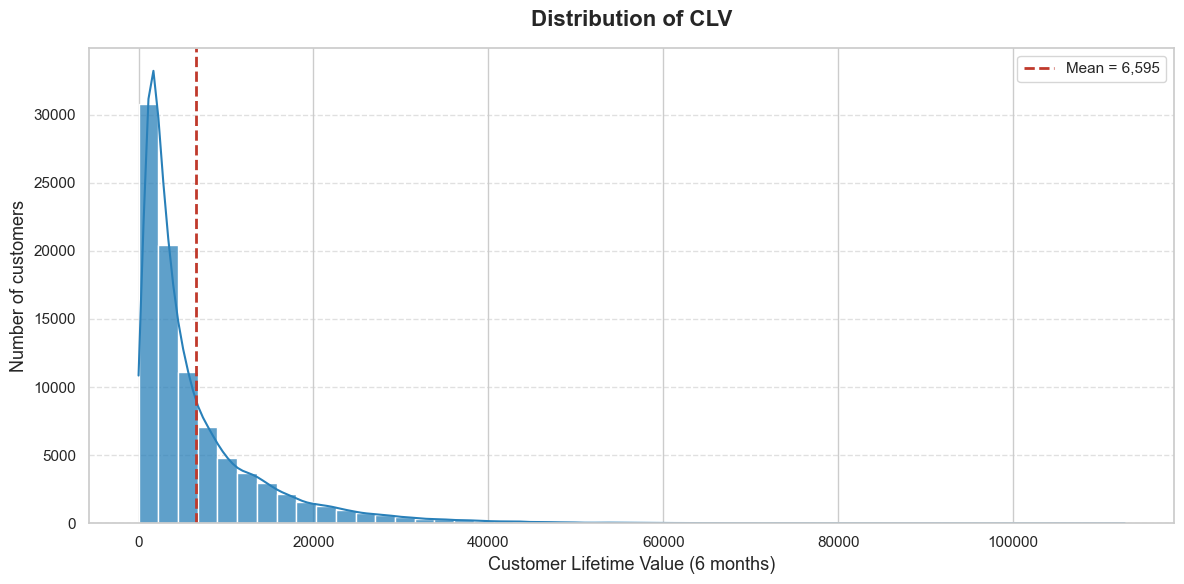

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 12

plt.figure(figsize=(12, 6))
ax = sns.histplot(
    summary["CLV_6m"].dropna(),
    bins=50,
    kde=True,
    color="#2980b9",
    alpha=0.75
)

avg_clv = summary["CLV_6m"].dropna().mean()
plt.axvline(avg_clv, color="#c0392b", linestyle="--", linewidth=2, label=f"Mean = {avg_clv:,.0f}")

ax.set_title("Distribution of CLV", fontsize=16, weight="bold", pad=16)
ax.set_xlabel("Customer Lifetime Value (6 months)", fontsize=13)
ax.set_ylabel("Number of customers", fontsize=13)
ax.grid(True, linestyle="--", alpha=0.6, axis="y")
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()